In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
import random
from pathlib import Path
from PIL import Image
import pandas as pd

import torch
import torch.optim as optim
import torch.nn as nn

from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

In [2]:
def set_seed(seed_value=123):
    
    random.seed(seed_value)          # Python random
    np.random.seed(seed_value)       # NumPy random
    torch.manual_seed(seed_value)    # PyTorch CPU

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)      # single GPU
        torch.cuda.manual_seed_all(seed_value)  # multi GPU

    # deterministic CUDA behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(123)

In [3]:
yes_dir = Path("brain_tumor_dataset/yes")
no_dir = Path("brain_tumor_dataset/no")

# Keep order deterministic and only use jpg/jpeg files
yes_files = sorted([
    os.path.join(yes_dir, f)
    for f in os.listdir(yes_dir)
    if f.lower().endswith(("jpg", "png","jpeg"))
])
no_files = sorted([
    os.path.join(no_dir, f)
    for f in os.listdir(no_dir)
    if f.lower().endswith(("jpg", "png","jpeg"))
])

print("Number of yes file:", len(yes_files))
print("Number of no file:", len(no_files))


Number of yes file: 155
Number of no file: 98


In [4]:
print(yes_files[:5])

['brain_tumor_dataset/yes/Y1.jpg', 'brain_tumor_dataset/yes/Y10.jpg', 'brain_tumor_dataset/yes/Y100.JPG', 'brain_tumor_dataset/yes/Y101.jpg', 'brain_tumor_dataset/yes/Y102.jpg']


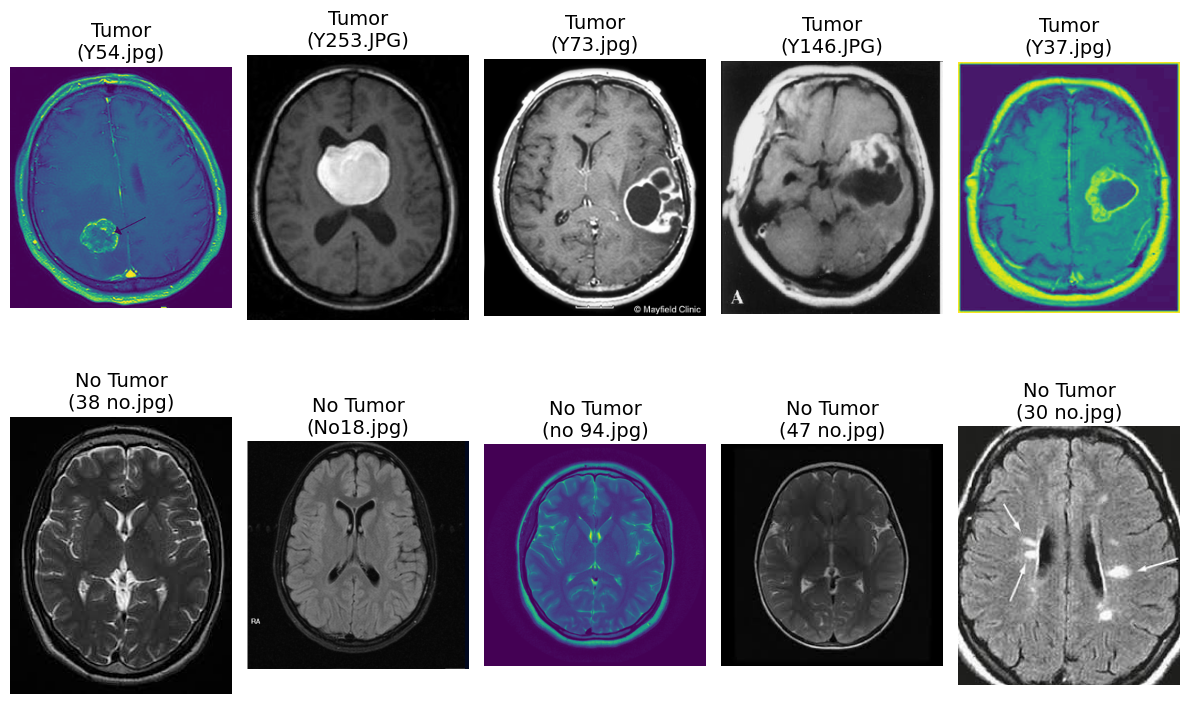

In [5]:
set_seed()

yes_idx = np.random.choice(len(yes_files), 5, replace=False) # replace=False >> no duplicates (sampling without replacement)
no_idx = np.random.choice(len(no_files), 5, replace=False)

yes_sample = [yes_files[i] for i in yes_idx]
no_sample = [no_files[i] for i in no_idx]

images = yes_sample + no_sample
labels = ["Tumor"] * 5 + ["No Tumor"] * 5

plt.figure(figsize=(12, 8))

for i, (img_path, label) in enumerate(zip(images, labels), 1):
    plt.subplot(2, 5, i)
    img = Image.open(img_path)
    plt.imshow(img)
    file_name = os.path.basename(img_path)  # e.g., Y109.JPG
    plt.title(f"{label}\n({file_name})", fontsize=14)  # filename in brackets
    plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
rows = []

for img_path, label in zip(images, labels):
    with Image.open(img_path) as im:
        arr = np.array(im)

        channels = 1 if arr.ndim == 2 else arr.shape[2]

        rows.append({
            "class": label,
            "file_name": os.path.basename(img_path),
            "format": im.format,
            "mode": im.mode,
            "height": im.height,
            "width": im.width,
            "channels": channels,
            "shape": arr.shape
        })

df_info = pd.DataFrame(rows)
display(df_info)

,class,file_name,format,mode,height,width,channels,shape
0,Tumor,Y54.jpg,JPEG,L,325,300,1,"(325, 300)"
1,Tumor,Y253.JPG,JPEG,RGB,338,283,3,"(338, 283, 3)"
2,Tumor,Y73.jpg,JPEG,RGB,290,250,3,"(290, 250, 3)"
3,Tumor,Y146.JPG,JPEG,RGB,355,311,3,"(355, 311, 3)"
4,Tumor,Y37.jpg,JPEG,L,360,319,1,"(360, 319)"
5,No Tumor,38 no.jpg,JPEG,RGB,251,201,3,"(251, 201, 3)"
6,No Tumor,No18.jpg,PNG,RGBA,454,442,4,"(454, 442, 4)"
7,No Tumor,no 94.jpg,JPEG,L,630,630,1,"(630, 630)"
8,No Tumor,47 no.jpg,JPEG,RGB,225,225,3,"(225, 225, 3)"
9,No Tumor,30 no.jpg,JPEG,RGB,242,208,3,"(242, 208, 3)"


In [ ]:
# JPEG is typically RGB -> 3 channels (or grayscale L -> 1 channel).
# PNG can be RGB (3), RGBA (4), or grayscale variants. :: eg. (6) No18.jpg	PNG	RGBA	454	442	4	(454, 442, 4)

In [25]:
img_path = "brain_tumor_dataset/yes/Y1.jpg"
img = Image.open(img_path).convert("RGB")

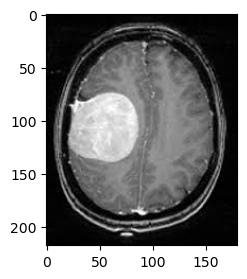

In [30]:
plt.figure(figsize=(4,3))
plt.imshow(img)


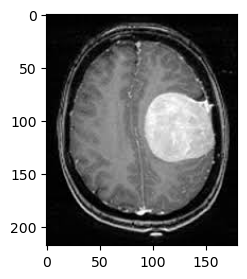

In [ ]:
plt.figure(figsize=(4,3))
plt.imshow(transforms.RandomHorizontalFlip(p=1.0)(img))

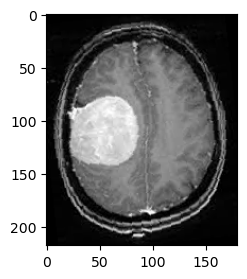

In [39]:
plt.figure(figsize=(4,3))
plt.imshow(transforms.RandomRotation(degrees=15)(img))

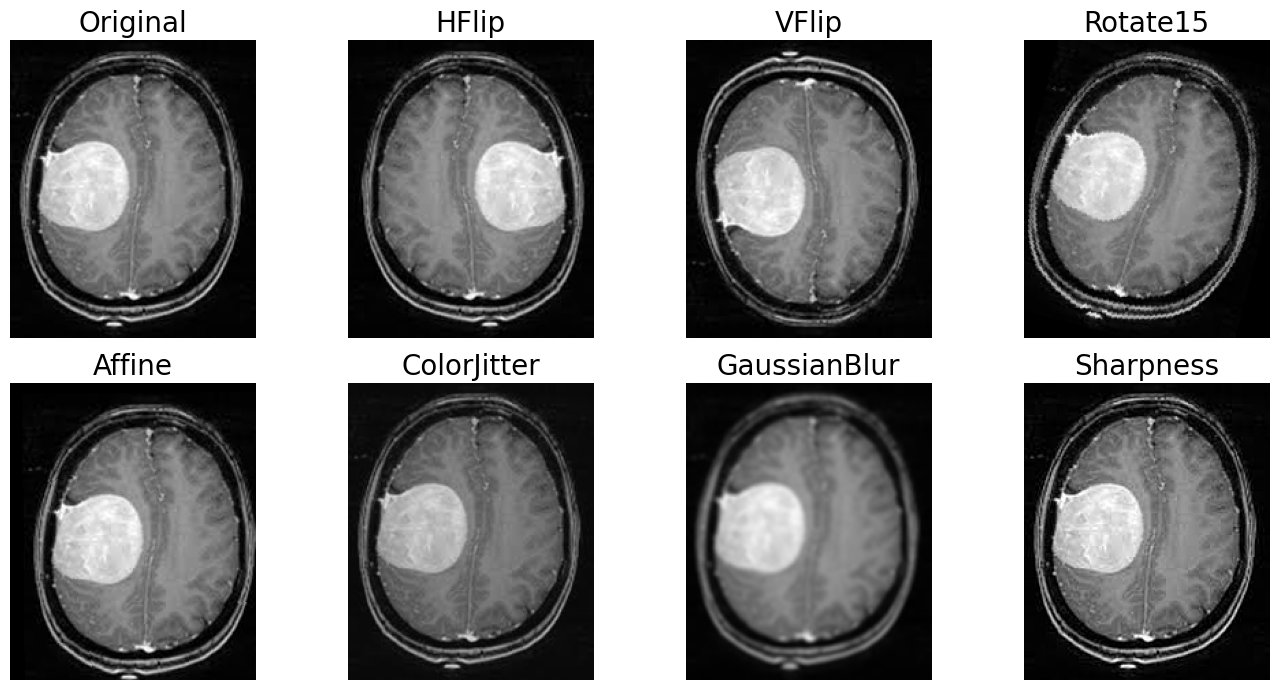

In [40]:
# Visualize single-image augmentation (one sample, multiple augmentations)

# pick one image
img_path = "brain_tumor_dataset/yes/Y1.jpg"
img = Image.open(img_path).convert("RGB")

# define augmentations
augs = [
    ("Original", None),
    ("HFlip", transforms.RandomHorizontalFlip(p=1.0)),
    ("VFlip", transforms.RandomVerticalFlip(p=1.0)),
    ("Rotate15", transforms.RandomRotation(degrees=15)),
    ("Affine", transforms.RandomAffine(degrees=8, translate=(0.08, 0.08), scale=(0.95, 1.05))),
    ("ColorJitter", transforms.ColorJitter(brightness=0.2, contrast=0.2)),
    ("GaussianBlur", transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))),
    ("Sharpness", transforms.RandomAdjustSharpness(sharpness_factor=2, p=1.0)),
]

# plot
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for ax, (name, aug) in zip(axes, augs):
    out = img if aug is None else aug(img)
    ax.imshow(out)
    ax.set_title(name, fontsize=20)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [42]:
##--
src_root = Path("brain_tumor_dataset")
dst_root = Path("augmented")
classes = ["yes", "no"]
##--
save_original = True
jpeg_quality = 95
valid_ext = (".jpg", ".jpeg", ".png")
##--
aug_transforms = [
    ("HFlip", transforms.RandomHorizontalFlip(p=1.0)),
    ("VFlip", transforms.RandomVerticalFlip(p=1.0)),
    ("Rotate10", transforms.RandomRotation(degrees=10)),
    ("Affine", transforms.RandomAffine(degrees=10, translate=(0.08, 0.08), scale=(0.95, 1.05), fill=0)),
    ("ColorJitter", transforms.ColorJitter(brightness=0.2, contrast=0.2)),
    ("GaussianBlur", transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))),
    ("Sharpness", transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=1.0)),
]
## --- create dirs
for cls in classes:
    (dst_root / cls).mkdir(parents=True, exist_ok=True)

def is_image_file(name: str) -> bool:
    return name.lower().endswith(valid_ext)

for cls in classes:
    src_dir = src_root / cls
    out_dir = dst_root / cls

    files = sorted([f for f in os.listdir(src_dir) if is_image_file(f)])

    for fname in files:
        in_path = src_dir / fname
        stem = Path(fname).stem.replace(" ", "-")

        # standardize to RGB (3-channel)
        img = Image.open(in_path).convert("RGB")

        # save original copy 
        if save_original:
            img.save(out_dir / f"{stem}_Original.jpg", format="JPEG", quality=jpeg_quality)

        # save one image per transform
        for aug_name, aug in aug_transforms:
            out = aug(img).convert("RGB")
            out.save(out_dir / f"{stem}_{aug_name}.jpg", format="JPEG", quality=jpeg_quality)

print("Done.")
# print("Saved to:", dst_root.resolve())
print("yes count:", len(os.listdir(dst_root / "yes")))
print("no count :", len(os.listdir(dst_root / "no")))


Done.
yes count: 1232
no count : 784
